# Testing the Runtime of Various Python Methods and Functions

## Platform

In [1]:
import platform, multiprocessing as mp
print(f"{platform.platform()} | Python {platform.python_implementation()} {platform.python_version()} | CPU={mp.cpu_count()} cores | Machine={platform.machine()}")

macOS-15.5-arm64-arm-64bit | Python CPython 3.11.7 | CPU=8 cores | Machine=arm64


## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import itertools

# 1D List Creation: List Comprehension VS List Multiplication VS For Loop VS Itertools Repeat

## Explanation

### List Comprehension
- loops over every value, creating a new object for each
- x = [1 for _ in range(num)] 
  - creates list containing a new "1" "num" times

### List Multiplication
- creates a list with pointers pointing to the same object
- implemented in C and doesn't execute Python bytecode (that's why it's faster)
- x = [1] * num
  - creates a list containing the same "1" "num" times
  - this creates aliasing and is a problem if you use a mutable type
    - ex. x = [[1]] * num
    - x is [[1], [1], [1],...] num size
    - but if you append to any one of them as so: x[1].append(9)
    - x is [[1, 9], [1, 9], [1, 9],...]
  - this is not a problem with immutable types like integers
    - if you change an immutable type, Python creates a new object

### Classic For Loop
- Not much to say, the classic for-loop

### Itertools Repeat
- implemented in C, so faster
- Make an iterator that returns object over and over again
- https://docs.python.org/3/library/itertools.html#itertools.repeat

## Trials
Average over 100 trials (mean per-loop time over 5 repeats, 20 loops each (seconds)) for the creation of 1D list sizes filled with 1s of sizes up to 1,000,000 with 100,000 element increments, starting at 1.

In [3]:
def testComprehension(num):
    x = [1 for _ in range(num + 1)]

def testMultiplication(num):
    x = [1] * (num + 1)

def testForLoop(num):
    x = []
    for i in range(num + 1):
        x.append(1)

def testItertoolsRepeat(num):
    x = list(itertools.repeat(1, num + 1))

def generate1DListTests():
    datasetSizes = list(range(1, 1000000, 100000))

    # n is how many trials per run 
    # r is how many runs
    # -o to capture the result object
    # -q for quiet so it doesn't print out the output

    results = {}

    data1 = []
    for n in datasetSizes:
        resData1 = %timeit -o -r 5 -n 20 -q testComprehension(n)
        data1.append({"n": n, "mean_s": resData1.average, "stdev_s": resData1.stdev})
    results["List Comprehension"] = pd.DataFrame(data1)

    data2 = []
    for n in datasetSizes:
        resData2 = %timeit -o -r 5 -n 20 -q testMultiplication(n)
        data2.append({"n": n, "mean_s": resData2.average, "stdev_s": resData2.stdev})
    results["List Multiplication"] = pd.DataFrame(data2)

    data3 = []
    for n in datasetSizes:
        resData3 = %timeit -o -r 5 -n 20 -q testForLoop(n)
        data3.append({"n": n, "mean_s": resData3.average, "stdev_s": resData3.stdev})
    results["List For Loop"] = pd.DataFrame(data3)

    data4 = []
    for n in datasetSizes:
        resData4 = %timeit -o -r 5 -n 20 -q testItertoolsRepeat(n)
        data4.append({"n": n, "mean_s": resData4.average, "stdev_s": resData4.stdev})
    results["Itertools Repeat"] = pd.DataFrame(data4)

    for label, df in results.items():
        plt.errorbar(
            df["n"], df["mean_s"],
            yerr=df["stdev_s"],
            fmt='o-',           
            capsize=4,         
            label=label
        )
    
    plt.xlabel("List sizes")
    plt.ylabel("Execution time (seconds)")
    plt.title(f"1D List Creation: \nList Comprehension VS List Multiplication VS For Loop VS Itertools Repeat")
    plt.legend(title="Functions")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Result

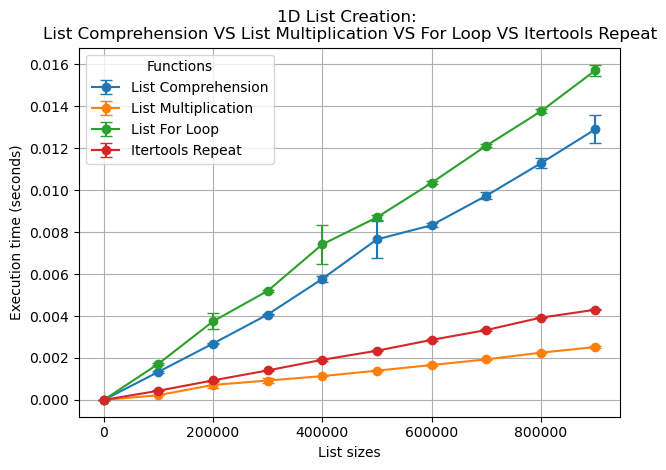

In [4]:
generate1DListTests()

# 2D Not Aliased List Creation: List Comprehension VS List Multiplication VS For Loop VS Itertools Repeat

## Explanations
All is the same as in 1D; however, for list multiplication and for itertools repeat we need to loop through the outer list in order to prevent aliasing. (The inner list is a list of immutable ints so we don't have to worry about aliasing there.)

## Trials
Average over 100 trials (mean per-loop time over 5 repeats, 20 loops each (seconds)) for the creation of 2D list sizes filled with 1s of sizes up to 1,000 with 100 element increments, starting at 1.

In [ ]:
def testComprehension(num):
    x = [[1 for __ in range(num + 1)] for _ in range(num + 1)]

def testMultiplication(num):
    x = [[1] * (num + 1) for _ in range(num+1)]

def testForLoop(num):
    x = []
    for i in range(num + 1):
        y = []
        for j in range(num + 1):
            y.append(1)
        x.append(y)

def testItertoolsRepeat(num):
    x = [list(itertools.repeat(1, num + 1)) for _ in range(num + 1)]

def generate2DListTests():
    datasetSizes = list(range(1, 1000, 100))

    # n is how many trials per run 
    # r is how many runs
    # -o to capture the result object
    # -q for quiet so it doesn't print out the output

    results = {}

    data1 = []
    for n in datasetSizes:
        resData1 = %timeit -o -r 5 -n 20 -q testComprehension(n)
        data1.append({"n": n, "mean_s": resData1.average, "stdev_s": resData1.stdev})
    results["List Comprehension"] = pd.DataFrame(data1)

    data2 = []
    for n in datasetSizes:
        resData2 = %timeit -o -r 5 -n 20 -q testMultiplication(n)
        data2.append({"n": n, "mean_s": resData2.average, "stdev_s": resData2.stdev})
    results["List Multiplication"] = pd.DataFrame(data2)

    data3 = []
    for n in datasetSizes:
        resData3 = %timeit -o -r 5 -n 20 -q testForLoop(n)
        data3.append({"n": n, "mean_s": resData3.average, "stdev_s": resData3.stdev})
    results["List For Loop"] = pd.DataFrame(data3)

    data4 = []
    for n in datasetSizes:
        resData4 = %timeit -o -r 5 -n 20 -q testItertoolsRepeat(n)
        data4.append({"n": n, "mean_s": resData4.average, "stdev_s": resData4.stdev})
    results["Itertools Repeat"] = pd.DataFrame(data4)

    for label, df in results.items():
        plt.errorbar(
            df["n"], df["mean_s"],
            yerr=df["stdev_s"],
            fmt='o-',           
            capsize=4,         
            label=label
        )

    plt.xlabel("List sizes")
    plt.ylabel("Execution time (seconds)")
    plt.title(f"2D Not Aliased List Creation: \nList Comprehension VS List Multiplication VS For Loop VS Itertools Repeat")
    plt.legend(title="Functions")
    plt.grid(True)
    plt.tight_layout()
    plt.show()




## Result

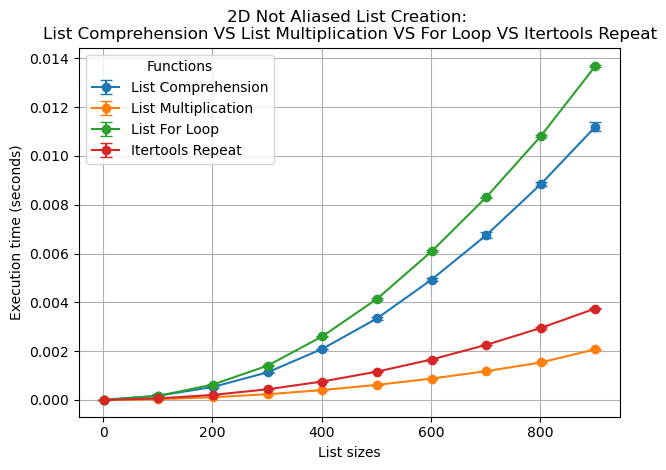

In [6]:
generate2DListTests()

# Credits
Author: Ryan Pelchat